# 🚗 Workshop: Fine-Tuning a Multi-Frame Vision-Language Model (DriveVLM-T5) for Driving Explanations

## 🎯 Learning Objectives
Upon completion of this notebook, you will be able to:
- **Explain** how a frozen Vision Transformer (ViT) and a text-based language model (T5) can be fused into a single Vision-Language Model (VLM)
- **Describe** how Gated Pooling Attention (GPA) combines multiple camera views (front, front-left, front-right, back, back-left, back-right) into one scene representation
- **Implement** a custom PyTorch `Dataset`/`collate_fn` pipeline for multi-image, question-answering data
- **Train** a VLM end-to-end with mixed-precision, checkpointing, and validation-based model selection
- **Recognize** how LoRA (Low-Rank Adaptation) is used to cheaply fine-tune large language models

## 📚 Prerequisites

Before running this notebook, you should be familiar with:

| Concept | Why It Matters Here |
|---|---|
| PyTorch Basics (`nn.Module`, Tensors) | Base definitions for custom architectural networks and layers |
| Vision Transformers (ViT) | Extracting spatial frame patch matrices from multi-view cameras |
| Encoder-Decoder Language Models (T5) | Sequence-to-sequence translation maps translating tokens into textual tokens |
| Attention Mechanisms | Query-Key-Value maps used to assign variable context weights across structural tokens |

**Software Dependencies**
- Python 3.9+
- `torch`, `torchvision`, `transformers`, `peft`, `tqdm`, `matplotlib`

## Part 1: Theoretical Background

### 1.1 The DriveLM Dataset Context
Autonomous decision-making engines rely on a nuanced understanding of road rules, lane configurations, and dynamic hazards. This workbook uses a curated subset of the **DriveLM (DriveVLM)** framework data, capturing holistic driving scene scenarios across 6 raw target camera perspectives:
```
           ┌───────────────┐
           │  Front Camera │
    ┌──────┴───────────────┴──────┐
    │ Front-Left     Front-Right  │
    │ Camera               Camera │
    └──────┬───────────────┬──────┘
    │ Back-Left       Back-Right  │
    │ Camera               Camera │
    └──────┬───────────────┬──────┘
           │  Back Camera  │
           └───────────────┘
```

Each scenario maps these synchronized spatial image feeds to continuous question-and-answer pairs focused on semantic understanding, spatial-temporal navigation context, and dynamic driving logic (e.g., *"What should the ego vehicle do next, and why?"*).

---

### 1.2 Multi-View Architecture & Gated Pooling Attention
DriveVLM-T5 refines the visual representations using a dedicated Gated Pooling Attention (GPA) module and a projection layer before fusing them with the language model.

1. **Frozen Spatial Patch Extraction:** Each frame feed gets encoded by a frozen Vision Transformer (`vit_b_32`) into spatial patch matrices.
2. **Gated Pooling Attention (GPA):** Rather than blindly averaging out context maps, a split hidden activation layer dynamically scores individual cameras based on current feature maps:
   - **Tanh branch** evaluates basic cross-token visual features.
   - **Sigmoid branch** functions as a situational selection gate.
   - Their intersection calculates a dynamic weight mask over the 6 points of view, enabling the network to lock its focus onto safety-critical feeds (e.g., prioritizing side cameras during active lane merges).
3. **Linear Projection:** A trainable projection layer maps the pooled multi-view embeddings to match the dimensional space of the T5 text embedding for seamless multimodal concatenation.

```
[6 Camera Inputs] ──► [Frozen ViT Patches] ──► [Gated Pooling Attention] ──► [Projection layer]──┐
                                                                                                 ▼
                                   [Question Text] ──► [Token Embedding Layer] ──────► [Concatenation Layer]
                                                                                                 │
                                                                                                 ▼
                                                                                       [T5 Encoder-Decoder]
                                                                                                 │
                                                                                                 ▼
                                                                                       [Generated Answer]
```                                                                                                  

## Part 2: Hands-On Framework Training

### Step 1: Import Libraries & Select Device

- **`torch` / `torch.nn`** — model building blocks and tensor operations
- **`torchvision`** — `read_image` to load JPEGs, `transforms` to resize/normalize them, and `vit_b_32` (a pretrained Vision Transformer) as our frozen image encoder
- **`transformers`** — Google's **T5** tokenizer and conditional-generation model, which will act as the "language brain" of the system
- **`peft`** — Hugging Face's Parameter-Efficient Fine-Tuning library, used later for **LoRA** when training the larger `T5-Large` variant
- **`tqdm`** — progress bars so training doesn't feel like a black box

The `device` line automatically picks a GPU if one is available, falling back to CPU otherwise — always check this print statement first, since training a VLM on CPU would be extremely slow.

In [ ]:
import os
import json
import time
import pandas as pd
import torch
import torch.nn as nn

%matplotlib inline
import matplotlib.pyplot as plt
from tqdm import tqdm
from copy import deepcopy

from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision import transforms
from torchvision.models import vit_b_32
from transformers import T5Tokenizer, T5ForConditionalGeneration
from peft import LoraConfig, get_peft_model, LoftQConfig

from torch.utils.data import Subset
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on device: {device}")

/home/exouser/.conda/envs/EM-VLM4AD/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device: cuda


### Step 2: Training Configuration

Key fields:

| Field | Meaning |
|---|---|
| `learning_rate` | Step size for the `AdamW` optimizer (`1e-4` is a common starting point for fine-tuning) |
| `batch_size` | Number of (question, 6-image, answer) triplets processed per training step |
| `gpa_hidden_size` | Hidden dimension used inside the Gated Pooling Attention module that fuses the 6 camera views |
| `lm` | Which T5 checkpoint to use — `'T5-Base'` (full fine-tune) or `'T5-Large'` (LoRA fine-tune) |


`VIT_HIDDEN_STATE` (768) and `VIT_SEQ_LENGTH` (49) describe the shape of the patch embeddings that come out of the ViT for a single 224×224 image (7×7 patches = 49 tokens, each 768-dimensional)

In [ ]:
# ==========================================
#           CONFIGURATION
# ==========================================
class TrainingConfig:
    learning_rate = 1e-4
    batch_size = 9        
    epochs = 1
    gpa_hidden_size = 128
    lm = 'T5-Base'        
    checkpoint_frequency = 1000                 # How often (in steps) to print a sample prediction as a sanity check
    lora = True                                 # Whether to apply LoRA adapters (only used when `lm != 'T5-Base'`)
    num_workers = 8                             # CPU worker processes for the `DataLoader`, so image loading happens in parallel with GPU compute
    
config = TrainingConfig()

VIT_HIDDEN_STATE = 768
VIT_SEQ_LENGTH = 49

### Step 3: Dataset Definition - `MultiFrameDataset`

* Each training example in the underlying JSON file is a `(question_answer_dict, image_paths_dict)` pair. 
* Under the hood, our training split from the **DriveLM (nuScenes)** dataset contains **377,983 multi-view/QA pairs** mapping **6 concurrent camera perspectives**
* `MultiFrameDataset` is a standard PyTorch `Dataset` that turns that raw JSON into tensors

#### Key Pipeline Components

- **`__getitem__`** loads all camera images for one scene with `read_image`, applies the `transform` pipeline (resize + normalize), and stacks them into a single tensor of shape `[num_views, 3, 224, 224]`. It also prefixes the question with `"Question: ... Answer:"`, a simple prompt template that tells T5 this is a QA task.
- **`collate_fn`** is what turns a *list* of individual examples into a single *batch*. It:
  1. Stacks the per-example image tensors into a batch tensor
  2. Tokenizes all questions in the batch together (with padding so they're the same length)
  3. Tokenizes all answers the same way to create `labels`

In [ ]:
# ==========================================
#           DATASET DEFINITION
# ==========================================
class MultiFrameDataset(Dataset):
    def __init__(self, input_file, tokenizer, transform=None):
        with open(input_file) as f:
            self.data = json.load(f)
        self.tokenizer = tokenizer
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        qa, img_path = self.data[idx]
        img_paths = list(img_path.values())
        
        q_text, a_text = qa['Q'], qa['A']
        q_text = f"Question: {q_text} Answer:"

        # Load and transform images 
        imgs = [self.transform(read_image(p).float()) for p in img_paths]
        imgs = torch.stack(imgs, dim=0)

        return q_text, imgs, a_text, sorted(list(img_path.values()))

    def collate_fn(self, batch):
        q_texts, imgs, a_texts, _ = zip(*batch)
        
        
        imgs = torch.stack(list(imgs), dim=0)

        encodings = self.tokenizer(q_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").input_ids
        labels = self.tokenizer(a_texts, padding=True, truncation=True, max_length=512, return_tensors="pt").input_ids

        # Replace pad tokens with -100 so the model doesn't try to learn blank spaces
        labels[labels == self.tokenizer.pad_token_id] = -100

        return encodings, imgs, labels

### Step 4: Multimodal Cross-Attention Architecture - `DriveVLMT5`

At the heart of the model is the seamless fusion of a **frozen spatial feature extractor** (Vision Transformer) and a **trainable text encoder-decoder** (T5).

#### 4.1 The Language Backbone
The language model acts as the "reasoning engine" of the VLM. During initialization (`DriveVLMT5.__init__`), the class loads a pre-trained sequence-to-sequence model:

* **`T5-Base` Configuration (~223M parameters):** Trained via a complete fine-tune of all weights during the final training stage.
* **`T5-Large-Q` Configuration (~769M parameters):** Wrapped with a **LoRA (Low-Rank Adaptation)** adapter to enable training on standard hardware.

#### 4.2 The Vision Backbone - `MultiViewProcessor` (MVP)
The `MultiViewProcessor` is a custom module tasked with converting $N=6$ raw, synchronized camera perspectives into a representation that T5 can "read" like typical text tokens. 

It executes this transformation in five distinct steps:

1. **Frozen Patch Extraction:**
    - We utilize a pre-trained **Vision Transformer (`vit_b_32`)** kept entirely **frozen** throughout training. 
    - For each of the $6$ cameras, an input image of size $224 \times 224$ is sliced and projected into $7 \times 7 = 49$ patch embeddings with a hidden spatial dimension of $768$.
2. **Coordinate Mapping:** 
    - The individual visual patches are passed through the ViT's native class-token aggregation and positional embedding layers. 
    - This preserves spatial awareness across patch rows and columns before they are flattened into visual embedding matrices.
3. **Gated Pooling Attention (GPA):**
    - GPA learns the directional importance of each view using twin projection networks acting as a filter.
    - `Z` (tanh branch) and `G` (sigmoid branch) each project the flattened embeddings into a small `gpa_hidden_size`-dim space
    - Their element-wise product, passed through a linear layer `w` and a `softmax`, produces an **attention weight per view**
    - The final fused embedding is the weighted sum of all 6 views
    - This allows the model to selectively "trust" and isolate specific cameras depending on the question asked (e.g., heavily weighting rear-facing cameras if asked about a tailgating vehicle, or side-views during an active lane merge).
4. **Cross-Modal Realignment Blocks:**
    - Because language token vectors and visual patch vectors originate from entirely separate coordinate systems, passing them to a transformer without modification will destabilize the self-attention calculations.
    - To address this two specialized realignment blocks were used:
        - **Linear Projection Layers:** A dedicated linear layer maps the visual hidden dimension ($H_I = 768$) to match the larger text token embedding dimension ($H_{T5} = 1024$), aligning both modalities in a shared vector space.
        - **Modal Identity Identifiers:** To prevent the T5 transformer from confusing linguistic structure with physical, spatial image patches, we maintain a binary modal embedding array (`nn.Embedding(2, hidden_size)`):
            * **Index `0` (Text):** Added to all text token embedding channels.
            * **Index `1` (Vision):** Added to all visual patch channels.
    - This provides a clear structural coordinate signal, allowing the self-attention layers to easily distinguish textual context from multi-view physical space.

5. **Concat and Forward Pass (Putting It Together):**
    - The final step concatenates the text tokens and the fused image tokens into a single, unified sequence tensor.
    - This merged matrix is fed directly to T5's custom encoder-decoder as `inputs_embeds`. 
    - The model is trained using standard cross-entropy loss over the vocabulary targets, dynamically optimizing the GPA and projection weights to align visual features directly with textual explanations.


In [ ]:
# ==========================================
#           MODEL DEFINITION
# ==========================================
def print_trainable_parameters(model):
    trainable_params, all_param = 0, 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(f"Trainable params: {trainable_params} | Total: {all_param} | Trainable%: {100 * trainable_params / all_param:.2f}%")

class DriveVLMT5(nn.Module):
    def __init__(self, config):
        super().__init__()
        
        # Load T5 text model
        if config.lm == 'T5-Base':
            self.model = T5ForConditionalGeneration.from_pretrained('google-t5/t5-base')
        else:
            self.model = T5ForConditionalGeneration.from_pretrained('google-t5/t5-large')
            loftq_config = LoftQConfig(loftq_bits=8)
            lora_config = LoraConfig(
                r=64, lora_alpha=32, loftq_config=loftq_config,
                lora_dropout=0.05, bias='none', target_modules=['q', 'v']
            )
            self.model = get_peft_model(self.model, lora_config)

        hidden_size = self.model.config.d_model
        print('Trainable Parameters for LM model:')
        print_trainable_parameters(self.model)

        self.mvp = self.MultiViewProcessor(config.gpa_hidden_size, hidden_size, config.lm, freeze=True)

    class MultiViewProcessor(nn.Module):
        def __init__(self, gpa_hidden_size, hidden_size, lm, freeze=False):
            super().__init__()
            self.img_model = vit_b_32(weights='DEFAULT')
            self.lm = lm
            self.modal_embeddings = nn.Embedding(2, hidden_size)
            self.modal_embeddings.weight.data.normal_(mean=0.0, std=0.02)

            if freeze:
                for param in self.img_model.parameters():
                    param.requires_grad = False

            self.w = nn.Linear(in_features=gpa_hidden_size, out_features=1)
            self.Z = nn.Sequential(
                nn.Linear(in_features=VIT_HIDDEN_STATE * VIT_SEQ_LENGTH, out_features=gpa_hidden_size, bias=False),
                nn.Tanh()
            )
            self.G = nn.Sequential(
                nn.Linear(in_features=VIT_HIDDEN_STATE * VIT_SEQ_LENGTH, out_features=gpa_hidden_size, bias=False),
                nn.Sigmoid()
            )

            if self.lm != 'T5-Base':
                self.img_projection_layer = nn.Linear(in_features=VIT_HIDDEN_STATE, out_features=hidden_size)

        def gpa(self, img_embeddings):
            gpa_weights = torch.softmax(self.w(self.Z(img_embeddings) * self.G(img_embeddings)), dim=0)
            return torch.sum(gpa_weights * img_embeddings, dim=0)

        def get_img_embedding(self, imgs):
            N = imgs.shape[0]
            merged_embedding = torch.stack([self.img_model._process_input(img) for img in imgs], dim=0)
            batch_class_tokens = self.img_model.class_token.expand(merged_embedding.shape[1], -1, -1).repeat(N, 1, 1, 1)
            merged_embedding = torch.cat([batch_class_tokens, merged_embedding], dim=2)
            merged_embedding += self.img_model.encoder.pos_embedding.repeat(N, 1, 1, 1)
            merged_embedding = merged_embedding[:, :, 1:]
            
            merged_embedding = torch.stack([self.gpa(embedding.flatten(start_dim=1)).reshape(VIT_SEQ_LENGTH, VIT_HIDDEN_STATE) for embedding in merged_embedding], dim=0)

            if self.lm != 'T5-Base':
                merged_embedding = self.img_projection_layer(merged_embedding)

            merged_embedding += self.modal_embeddings(torch.ones((1, merged_embedding.shape[1]), dtype=torch.int, device=device))
            return merged_embedding

        def forward(self, text_enc, imgs, text_model):
            imgs_embedding = self.get_img_embedding(imgs)
            text_embeddings = text_model.get_input_embeddings()(text_enc)
            text_embeddings += self.modal_embeddings(torch.zeros((1, text_embeddings.shape[1]), dtype=torch.int, device=device))
            merged_embedding = torch.cat([text_embeddings, imgs_embedding], dim=1)
            return merged_embedding

    def forward(self, text_enc, imgs, labels=None):
        merged_embedding = self.mvp(text_enc, imgs, self.model)
        return self.model(inputs_embeds=merged_embedding, labels=labels)

### Step 5: Training Helper Functions

Three small utilities support the main training loop:

- **`save_model`** - writes model weights to `multi_frame_results/<timestamp>/<name>.pth`, namespaced by a timestamp so each run gets its own folder
- **`val_model`** - runs a full pass over the validation `DataLoader` in `model.eval()` mode with gradients disabled (`torch.no_grad()`), returning the average validation loss. This is used after every epoch to check for overfitting and to decide whether to save a new "best" checkpoint
- **`plot_loss`** - plots training vs. validation loss curves after training finishes, so you can visually confirm the model is actually learning (and check for a widening train/val gap, a classic overfitting signal)

In [ ]:
# ==========================================
#            TRAINING HELPERS
# ==========================================
def save_model(model_state, model_name, timestr):
    path = os.path.join('multi_frame_results', timestr, model_name + '.pth')
    torch.save(model_state, path)

def val_model(dloader, val_model):
    val_model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, imgs, labels in tqdm(dloader, desc="Validating", leave=False):

            # Move to GPU here
            inputs, imgs, labels = inputs.to(device), imgs.to(device), labels.to(device)

            outputs = val_model(inputs, imgs, labels)
            val_loss += outputs.loss.mean().item()
    return val_loss / len(dloader)

def plot_loss(training_loss, val_loss):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(training_loss) + 1), training_loss, label='Training Loss', marker='o')
    plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', marker='o')
    plt.title('Model Learning Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

### Step 6: Core Training Loop - `custom_train`

This function implements a standard supervised fine-tuning loop:

- **Optimizer & Scheduler**: `AdamW` (the standard choice for transformer fine-tuning) paired with an `ExponentialLR` scheduler (`gamma=0.9`) that gradually decays the learning rate each epoch, helping the model settle into a good minimum
- **Mixed Precision (`torch.cuda.amp`)**: The forward pass runs under `autocast(dtype=torch.bfloat16)`, which performs many operations in lower precision to save GPU memory and increase throughput, while `GradScaler` helps keep gradients numerically stable
- **Best-model checkpointing**: After each epoch, if validation loss improves, the model weights are deep-copied and saved - this protects against overfitting in later epochs by always keeping the *best*, not just the *last*, checkpoint
- **Return value**: The function returns the best model's `state_dict`, which the `eval.ipynb` and `Run-DriveLM.ipynb` notebooks will later load back in for evaluation and inference

In [ ]:
# ==========================================
#            CORE TRAINING LOOP
# ==========================================
def custom_train(model, processor, train_dataloader, val_dataloader, config, timestr):
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
    scaler = torch.cuda.amp.GradScaler()

    losses, val_losses = [], []
    min_val_loss = None
    best_model_weights = None

    for epoch in range(config.epochs):
        print(f'\n--- EPOCH {epoch + 1}/{config.epochs} ---')
        model.train()
        epoch_loss = 0

        train_bar = tqdm(train_dataloader, desc=f"Training Ep {epoch+1}")
        
        for step, (inputs, imgs, labels) in enumerate(train_bar):

            # Move to GPU here!
            inputs, imgs, labels = inputs.to(device), imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            
            # Forward pass with mixed precision
            with torch.cuda.amp.autocast(dtype=torch.bfloat16):
                outputs = model(inputs, imgs, labels)
                # Add .mean() to handle multi-GPU loss outputs!
                loss = outputs.loss.mean() 
            
            epoch_loss += loss.item()

            # Backpropagation
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_bar.set_postfix(loss=f"{loss.item():.4f}")

            if step > 0 and step % config.checkpoint_frequency == 0:
                print(f'\n--- Step {step} Quick Check ---')
                predicted_tokens = torch.argmax(outputs.logits, dim=-1)
                pred_text = processor.decode(predicted_tokens[0].to('cpu'), skip_special_tokens=True)
                true_text = processor.decode(labels[0].to('cpu'), skip_special_tokens=True)
                print(f"Model Prediction: {pred_text}")
                print(f"True Answer: {true_text}\n")

        # Evaluate Epoch
        epoch_train_loss = epoch_loss / len(train_dataloader)
        epoch_val_loss = val_model(val_dataloader, model)
        
        losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)

        print(f'Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}')

        # Save Best Model
        if min_val_loss is None or epoch_val_loss < min_val_loss:
            min_val_loss = epoch_val_loss
            best_model_weights = deepcopy(model.state_dict())
            save_model(best_model_weights, 'best_model', timestr)
            print("New best model saved!")

        scheduler.step()

    plot_loss(losses, val_losses)
    return best_model_weights

### Step 7: Initialize the Experiment, Model, and Tokenizer

This cell kicks off an actual training run:
- A timestamped output folder (e.g. `multi_frame_results/20260705-142230/`) is created so every experiment's checkpoints and logs are kept separate
- `DriveVLMT5(config)` builds the full model described in Step 4 and moves it to `device`
- If more than one GPU is visible, `nn.DataParallel` automatically splits each batch across GPUs — this is why the training loop needed to call `.mean()` on the loss
- The **T5 tokenizer** is loaded to match whichever backbone (`t5-base`/`t5-large`) was chosen, and a `<` token is explicitly added because some DriveLM-style question/answer templates use `<c1,CAM_FRONT,x,y>`-style object references, so this ensures `<` isn't split awkwardly during tokenization
- `transform_pipeline` resizes every camera image to `224×224` (the input size ViT expects) and normalizes pixel values to roughly `[-1, 1]` using a mean/std of `127.5`

In [ ]:
# ==========================================
#           EXECUTION SCRIPT
# ==========================================
timestr = time.strftime("%Y%m%d-%H%M%S")
os.makedirs(os.path.join('multi_frame_results', timestr), exist_ok=True)
print(f"Saving experiment to folder: {timestr}")

# Initialize Model & Processor
print("Loading model architecture...")
model = DriveVLMT5(config).to(device)

if torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

processor = T5Tokenizer.from_pretrained('google-t5/t5-base' if config.lm == 'T5-Base' else 'google-t5/t5-large')
processor.add_tokens('<')

# Load Data Pipelines
transform_pipeline = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize((127.5, 127.5, 127.5), (127.5, 127.5, 127.5))
])

Saving experiment to folder: 20260703-164941
Loading model architecture...
Trainable Parameters for LM model:
Trainable params: 222903552 | Total: 222903552 | Trainable%: 100.00%


/home/exouser/.conda/envs/EM-VLM4AD/lib/python3.12/site-packages/transformers/models/t5/tokenization_t5.py:246: FutureWarning: This tokenizer was incorrectly instantiated with a model max length of 512 which will be corrected in Transformers v5.
For now, this behavior is kept to avoid breaking backwards compatibility when padding/encoding with `truncation is True`.
- Be aware that you SHOULD NOT rely on google-t5/t5-base automatically truncating your input to 512 when padding/encoding.
- If you want to encode/pad to sequences longer than 512 you can either instantiate this tokenizer with `model_max_length` or pass `max_length` when encoding/padding.
- To avoid this warning, please instantiate this tokenizer with `model_max_length` set to your preferred value.
  warnings.warn(
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing chan

Let's use 3 GPUs!


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


### Step 8: Load the Dataset 

The full `MultiFrameDataset` is loaded from the pre-processed DriveLM JSON files (`multi_frame_train.json`, `multi_frame_val.json`), which together contain **hundreds of thousands** of question-answer-image triplets.

To keep the exercise interactive, the notebook uses `torch.utils.data.Subset` with `random.sample` to carve out a small, random slice of the data:
- `DEMO_TRAIN_SIZE = 1500` examples instead of ~341,000
- `DEMO_VAL_SIZE = 250` examples instead of ~500

> **Note:** Because the subset is random and small, we cannot expect production-quality results in this notebook. The goal is to see the *full pipeline run end-to-end* (data → model → loss → checkpoint) in a few minutes rather than a few hours. For a real experiment, you would remove the `DEMO_*` subsetting and train on the full dataset.

In [ ]:
print("Loading datasets (this may take a moment)...")
train_dset = MultiFrameDataset(os.path.join('data', 'multi_frame', 'multi_frame_train.json'), processor, transform_pipeline)
val_dset = MultiFrameDataset(os.path.join('data', 'multi_frame', 'multi_frame_val.json'), processor, transform_pipeline)

# --- Create a small subset of the data ---
DEMO_TRAIN_SIZE = 1500  # Train on 1,500 examples instead of 341,000
DEMO_VAL_SIZE = 250     # Validate on 250 examples

# Get random indices
train_indices = random.sample(range(len(train_dset)), DEMO_TRAIN_SIZE)
val_indices = random.sample(range(len(val_dset)), DEMO_VAL_SIZE)

# Create the Subsets
train_dset_demo = Subset(train_dset, train_indices)
val_dset_demo = Subset(val_dset, val_indices)

# Give the DATALOADER the new demo datasets
train_dataloader = DataLoader(train_dset_demo, shuffle=True, batch_size=config.batch_size, num_workers=config.num_workers, pin_memory=True, collate_fn=train_dset.collate_fn)
val_dataloader = DataLoader(val_dset_demo, shuffle=False, batch_size=config.batch_size, num_workers=config.num_workers, pin_memory=True, collate_fn=train_dset.collate_fn)

Loading datasets (this may take a moment)...


### Step 9: Run Training

This final cell calls `custom_train(...)`, which will:
1. Loop over `config.epochs` epoch(s)
2. Evaluate on the validation set and save the best checkpoint at the end of the epoch
3. Plot the final training/validation loss curve

Once this finishes, the saved checkpoint (`multi_frame_results/<timestamp>/best_model.pth`) is exactly what `eval.ipynb` loads to compute quantitative metrics, and what `Run-DriveLM.ipynb` loads to generate qualitative, human-readable predictions on new driving scenes.

Starting training sequence...

--- EPOCH 1/1 ---


Training Ep 1:   0%|          | 0/167 [00:00<?, ?it/s]/home/exouser/.conda/envs/EM-VLM4AD/lib/python3.12/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at /opt/conda/conda-bld/pytorch_1708025824022/work/aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,
/home/exouser/.conda/envs/EM-VLM4AD/lib/python3.12/site-packages/torch/nn/parallel/_functions.py:68: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn('Was asked to gather along dimension 0, but all '
Training Ep 1: 100%|██████████| 167/167 [02:30<00:00,  1.11it/s, loss=0.5669]


Train Loss: 1.9997 | Val Loss: 1.0461
New best model saved!


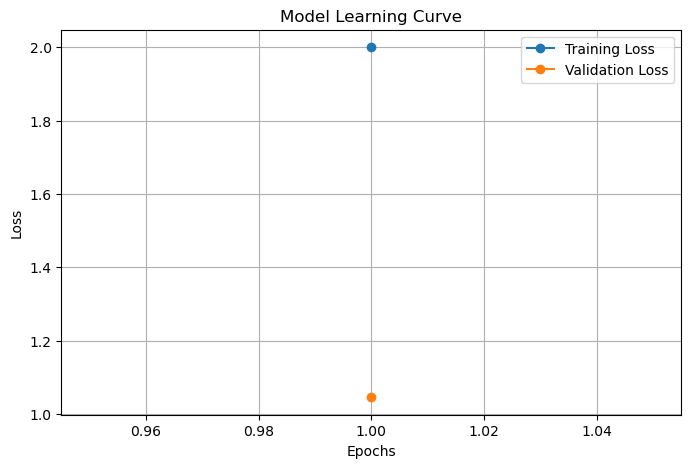

Training Complete!


In [9]:
# Start Training
print("Starting training sequence...")
best_weights = custom_train(model, processor, train_dataloader, val_dataloader, config, timestr)
print("Training Complete!")

## ✅ Recap
You just trained a multi-view, vision-language model that fuses 6 camera feeds with a T5 language model using Gated Pooling Attention, and optionally LoRA for parameter-efficient fine-tuning of larger backbones.

### Before you go, think about the following questions:
- Why is it important to freeze the ViT weights instead of fine-tuning the whole vision encoder alongside T5?
- What might happen to training stability if `bfloat16` mixed precision were replaced with full `float32`?
- The demo subset uses only 1,500 training examples. How might you expect Action/Justification CIDEr scores to change if trained on the full ~341K examples?
- Gated Pooling Attention learns a soft weighting over the 6 camera views. Can you think of a driving scenario where this weighting should look very different from a simple average?

## ⏱️ Estimated Time: 30–60 minutes (workshop demo subset)